In [79]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, TensorDataset
import matplotlib.pyplot as plt

In [80]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [81]:
!wget -q https://raw.githubusercontent.com/karpathy/makemore/refs/heads/master/names.txt

In [82]:
with open("names.txt", "r") as f:
    words = f.read().splitlines()

In [83]:
chars = sorted(list(set(''.join(words))))

stoi = {ch: i+1 for i, ch in enumerate(chars)}
stoi['.'] = 0
itos = {i: s for s, i in stoi.items()}

vocab_size = len(stoi)
vocab_size

27

In [84]:
block_size = 4
X, y = [], []

for w in words:
    context = [0] * block_size
    for ch in w + '.':
        ix = stoi[ch]
        X.append(context)
        y.append(ix)
        context = context[1:] + [ix]

X = torch.tensor(X)
y = torch.tensor(y)

print(X.shape, y.shape)

torch.Size([228146, 4]) torch.Size([228146])


In [85]:
train_size = int(0.8 * X.shape[0])

Xtr, Xts = X[:train_size], X[train_size:]
Ytr, Yts = y[:train_size], y[train_size:]

DLtr = DataLoader(TensorDataset(Xtr, Ytr), batch_size=1024, shuffle=True, drop_last=True)
DLts = DataLoader(TensorDataset(Xts, Yts), batch_size=1024, shuffle=False)

In [86]:
config = {
    "block_size": block_size,
    "vocab_size": vocab_size,
    "hidden_sizes": [256, 256, 256],
    "n_emb": 64
}

class MLP(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.block_size = config["block_size"]
        self.vocab_size = config["vocab_size"]
        self.n_emb = config["n_emb"]
        self.hidden_sizes = config["hidden_sizes"]

        self.E = nn.Embedding(self.vocab_size, self.n_emb)
        self.flat = nn.Flatten()

        layers = []
        input_size = self.n_emb * self.block_size
        for hs in self.hidden_sizes:
          layers.append(nn.Linear(input_size, hs))
          layers.append(nn.ReLU())
          input_size = hs

        layers.append(nn.Linear(input_size, vocab_size))

        self.net = nn.Sequential(*layers)

    def forward(self, X):
        X = self.E(X)      # (B, 3, emb)
        X = self.flat(X)   # flatten
        logits = self.net(X)
        return logits


In [87]:
model = MLP(config).to(device)

In [88]:
@torch.no_grad()
def evaluation(dataset):
    model.eval()
    total_loss = 0.0
    for xb, yb in dataset:
        xb, yb = xb.to(device), yb.to(device)
        logits = model(xb)
        loss = F.cross_entropy(logits, yb)
        total_loss += loss.item()
    return total_loss / len(dataset)

In [89]:
def train_model(epochs=20, lr=0.01):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    train_losses = []
    val_losses   = []

    print("Training model \n")

    for epoch in range(1, epochs + 1):
        model.train()
        epoch_loss = 0.0
        for xb, yb in DLtr:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            loss = F.cross_entropy(logits, yb)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()

        # Finding avarage
        avg_train_loss = epoch_loss / len(DLtr)
        avg_val_loss = evaluation(DLts)

        # Saving losses
        train_losses.append(avg_train_loss)
        val_losses.append(avg_val_loss)

        print(f"Epoch {epoch:2d} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")

    return train_losses, val_losses


Training model 

Epoch  1 | Train Loss: 2.2583 | Val Loss: 2.3794
Epoch  2 | Train Loss: 2.0942 | Val Loss: 2.3577
Epoch  3 | Train Loss: 2.0449 | Val Loss: 2.3193
Epoch  4 | Train Loss: 2.0182 | Val Loss: 2.3265
Epoch  5 | Train Loss: 1.9966 | Val Loss: 2.3414
Epoch  6 | Train Loss: 1.9806 | Val Loss: 2.3370
Epoch  7 | Train Loss: 1.9674 | Val Loss: 2.3179
Epoch  8 | Train Loss: 1.9554 | Val Loss: 2.3208
Epoch  9 | Train Loss: 1.9437 | Val Loss: 2.3302
Epoch 10 | Train Loss: 1.9342 | Val Loss: 2.3354
Epoch 11 | Train Loss: 1.9290 | Val Loss: 2.3219
Epoch 12 | Train Loss: 1.9228 | Val Loss: 2.3382
Epoch 13 | Train Loss: 1.9163 | Val Loss: 2.3402
Epoch 14 | Train Loss: 1.9085 | Val Loss: 2.3309
Epoch 15 | Train Loss: 1.9040 | Val Loss: 2.3473
Epoch 16 | Train Loss: 1.8988 | Val Loss: 2.3426
Epoch 17 | Train Loss: 1.8933 | Val Loss: 2.3652
Epoch 18 | Train Loss: 1.8900 | Val Loss: 2.3406
Epoch 19 | Train Loss: 1.8871 | Val Loss: 2.3569
Epoch 20 | Train Loss: 1.8839 | Val Loss: 2.3496


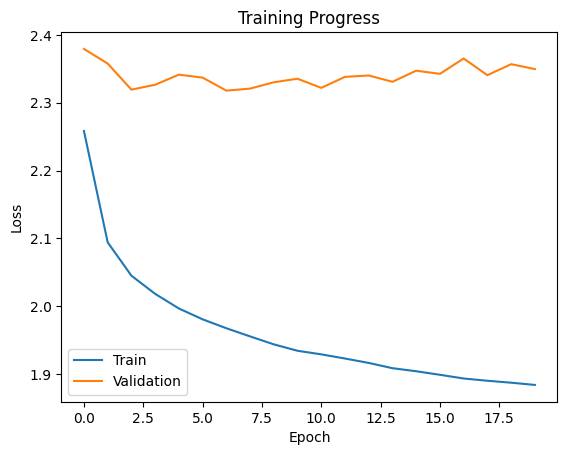

In [90]:
train_losses, val_losses = train_model(epochs=20, lr=0.01)

# Grafik
plt.plot(train_losses, label="Train")
plt.plot(val_losses,   label="Validation")
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Progress")
plt.show()

In [91]:
@torch.no_grad()
def generate_name(model, max_len=20):
    model.eval()
    context = [0] * block_size
    name = []

    for _ in range(max_len):
        x = torch.tensor([context], dtype=torch.long).to(device)
        logits = model(x)
        probs = F.softmax(logits, dim=-1)

        ix = torch.multinomial(probs, num_samples=1).item()

        if ix == 0:
            break

        name.append(itos[ix])
        context = context[1:] + [ix]

    return "".join(name)


In [92]:
for _ in range(20):
    print(generate_name(model))


adilyna
reigh
aumy
tenessy
heloisa
eshon
azufira
elliceonixon
eln
dabuna
jamelar
lada
nirva
micla
chukwu
irian
eddick
lupi
kaiziyah
chor
